In [4]:
#国内某航空公司面临着常旅客流失、竞争力下降和航空资源未充分利用等经营危机
#要建立合理的客户价值评估模型，对客户进行分类，分析比较不同客户群体的价值，并制定相应的营销策略

#初始化 导入变量
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib import rcParams
rcParams['font.sans-serif'] = ['SimHei']
rcParams['axes.unicode_minus'] = False

#数据探索分析
air_data_path = r'D:\PythonProject\air_data.csv'
air_data = pd.read_csv(air_data_path,encoding='utf-8')
explore = air_data.describe(percentiles=[],include='all').T
explore['null'] = len(air_data) - explore['count']
explore = explore[['null','max','min']]
explore.columns = [u'空值数',u'最大值',u'最小值']
explore

,空值数,最大值,最小值
MEMBER_NO,0.0,62988.0,1.0
FFP_DATE,0,NaN,NaN
FIRST_FLIGHT_DATE,0,NaN,NaN
GENDER,3,NaN,NaN
FFP_TIER,0.0,6.0,4.0
WORK_CITY,2269,NaN,NaN
WORK_PROVINCE,3248,NaN,NaN
WORK_COUNTRY,26,NaN,NaN
AGE,420.0,110.0,6.0
LOAD_TIME,0,NaN,NaN


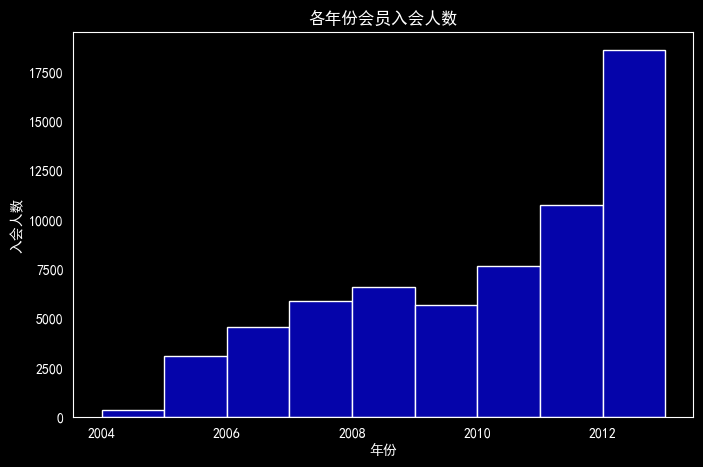

In [24]:
#分布分析(客户基本信息分布分析)
#选取客户基本信息中的入会时间、性别、会员卡级别和年龄字段进行探索分析
import datetime as dt
air_data['FFP_DATE'] = pd.to_datetime(air_data['FFP_DATE'])
ffp_year = air_data['FFP_DATE'].dt.year
fig = plt.figure(figsize = (8,5))
plt.hist(ffp_year,bins='auto',color='#0504aa')
plt.xlabel('年份')
plt.ylabel('入会人数')
plt.title('各年份会员入会人数')
plt.grid(False)
plt.show()


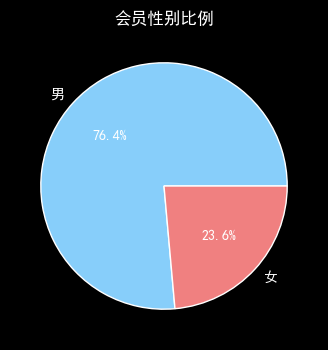

In [21]:
# 提取会员不同性别人数
male = air_data['GENDER'].value_counts()['男']
female = air_data['GENDER'].value_counts()['女']
fig = plt.figure(figsize = (7,4))
plt.pie([male,female],labels=['男','女'],colors=['lightskyblue','lightcoral'],autopct='%1.1f%%')
plt.title('会员性别比例')
plt.show()


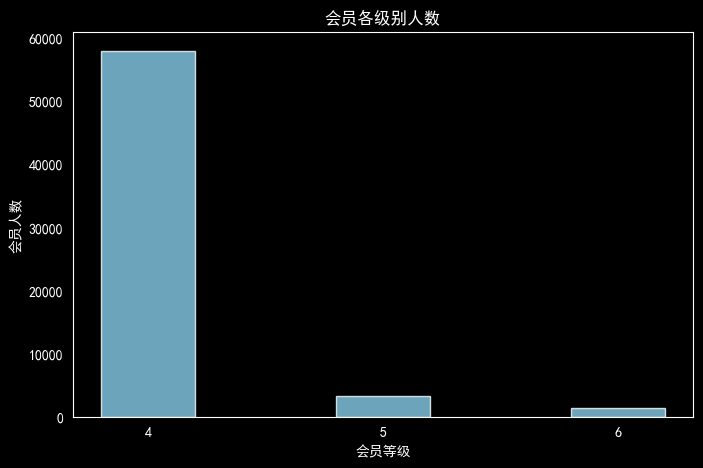

In [25]:
lv_four = air_data['FFP_TIER'].value_counts()[4]
lv_five = air_data['FFP_TIER'].value_counts()[5]
lv_six = air_data['FFP_TIER'].value_counts()[6]
fig = plt.figure(figsize = (8,5))
plt.bar(range(3),height=[lv_four,lv_five,lv_six],width=0.4,alpha=0.8,color='skyblue')
plt.xticks([index for index in range(3)],['4','5','6'])
plt.ylabel('会员人数')
plt.xlabel('会员等级')
plt.title('会员各级别人数')
plt.grid(False)
plt.show()

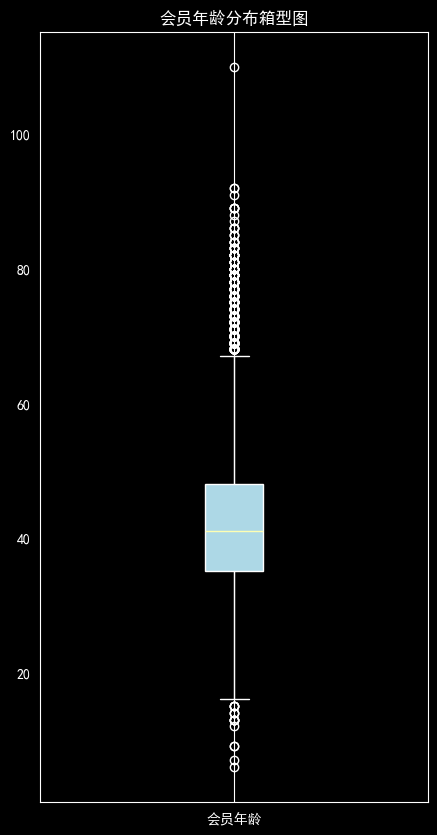

In [30]:
#探索年龄
age = air_data['AGE'].dropna()
age = age.astype('int64')
fig = plt.figure(figsize = (5,10))
plt.boxplot(age,patch_artist=True,tick_labels=['会员年龄'],boxprops={'facecolor':'lightblue'})
plt.title('会员年龄分布箱型图')
plt.grid(axis='y')
plt.show()
#可以看出大部分会员年龄集中在30～50岁之间，极少量的会员年龄小于20岁或高于60岁，且存在一个超过100岁的异常数据

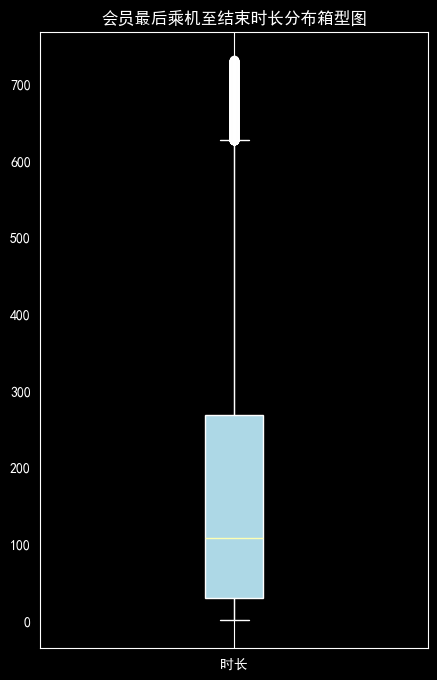

In [31]:
#客户乘机信息分布分析
# （绘制最后乘机至结束时长箱线图,由图可知: 客户的入会时长主要分布在50～300区间内，另外有一部分客户群体的入会时长分布在600以上的区间，可分为两个群体）
lte = air_data['LAST_TO_END']
fc = air_data['FLIGHT_COUNT']
sks = air_data['SEG_KM_SUM']

fig = plt.figure(figsize=(5,8))
plt.boxplot(lte,patch_artist=True,tick_labels=['时长'],boxprops={'facecolor':'lightblue'})
plt.title('会员最后乘机至结束时长分布箱型图')
plt.grid(axis='y')
plt.show()

C:\Users\Sterl\AppData\Local\Temp\ipykernel_24248\1020791945.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(fc,


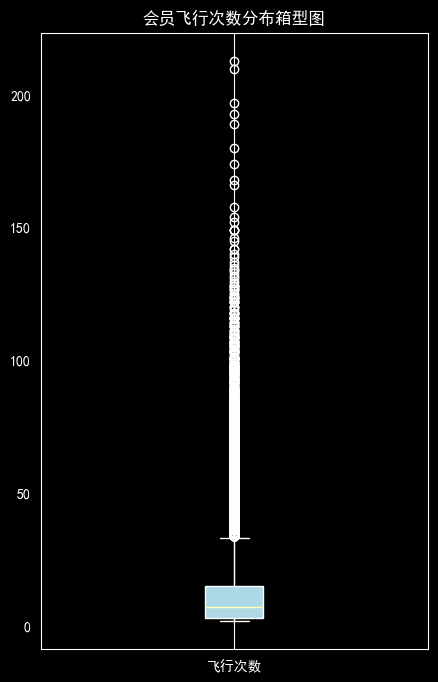

In [36]:
fig = plt.figure(figsize=(5,8))
plt.boxplot(fc,
             patch_artist=True,
             tick_labels=['飞行次数'],
             boxprops={'facecolor':'lightblue'}
)
plt.title('会员飞行次数分布箱型图')
plt.grid(axis='y')
plt.show()


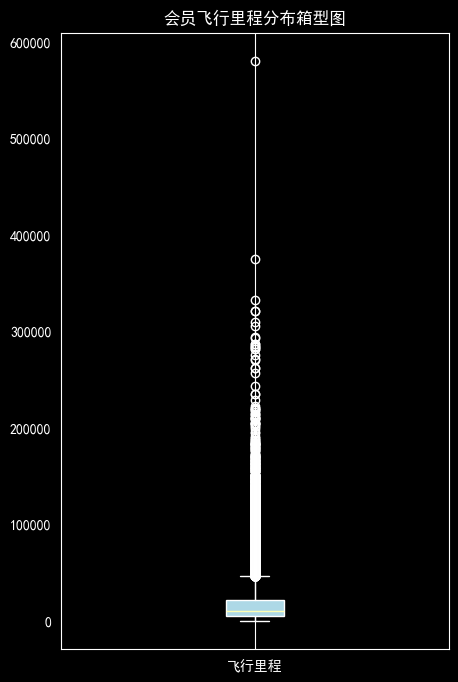

In [41]:
fig=plt.figure(figsize=(5,8))
plt.boxplot(sks,
            patch_artist=True,
            tick_labels= ['飞行里程'],
            boxprops={'facecolor':'lightblue'}
            )
plt.title('会员飞行里程分布箱型图')
plt.grid(axis='y')
plt.show()
#客户的飞行次数与总飞行公里数也明显地分为两个群体，大部分客户集中在箱型图下方的箱体中
#少数客户分散分布在箱体上界的上方，这部分客户很可能是高价值客户，因为其飞行次数和总飞行公里数明显超过箱体内的其他客户

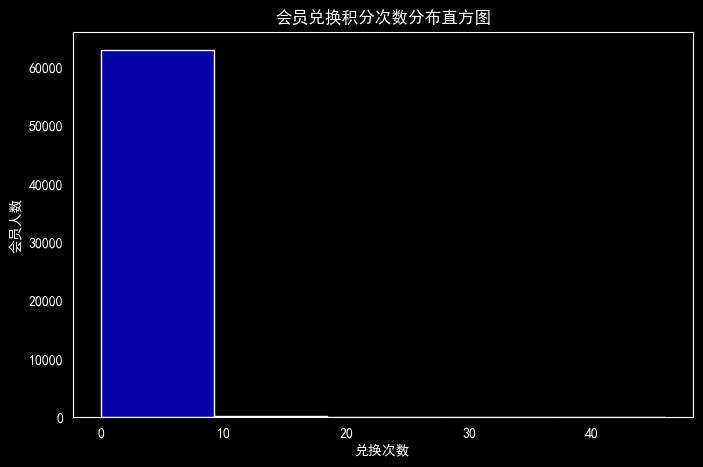

In [45]:
#提取会员积分兑换次数
ec = air_data['EXCHANGE_COUNT']
fig = plt.figure(figsize=(8,5))
plt.hist(ec,bins=5,color='#0504aa',edgecolor='white')
plt.xlabel('兑换次数')
plt.ylabel('会员人数')
plt.title('会员兑换积分次数分布直方图')
plt.grid(False)
plt.show()
#绘制会员兑换积分次数直方图,绝大部分客户的兑换次数在0～10的区间内，这表示大部分客户都很少进行积分兑换

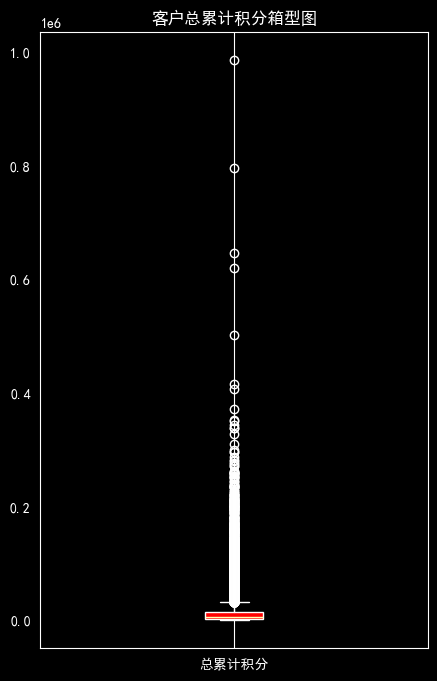

In [49]:
#绘制会员总累计积分箱线图,一部分客户集中在箱体中，少部分客户分散分布在箱体上方，这部分客户的积分要明显高于箱体内的客户的积分
#绘制会员总累计积分箱线图可见，数据呈现出显著的右偏分布。箱体极度扁平并压缩在低分区间，说明超过 75% 的会员积分水平较低；而箱体上方存在密集的离群点，这些高净值客户的积分规模远超普通会员，是航空公司价值贡献的核心来源。
ps = air_data['Points_Sum']
fig = plt.figure(figsize=(5,8))
plt.boxplot(
    ps,
    patch_artist=True,
    tick_labels=['总累计积分'],
    boxprops={'facecolor':'red'}
)
plt.title('客户总累计积分箱型图')
plt.grid(axis='y')

相关性矩阵为：
                 FFP_TIER  FLIGHT_COUNT  LAST_TO_END  SEG_KM_SUM  \
FFP_TIER        1.000000      0.582447    -0.206313    0.522350   
FLIGHT_COUNT    0.582447      1.000000    -0.404999    0.850411   
LAST_TO_END    -0.206313     -0.404999     1.000000   -0.369509   
SEG_KM_SUM      0.522350      0.850411    -0.369509    1.000000   
EXCHANGE_COUNT  0.342355      0.502501    -0.169717    0.507819   
Points_Sum      0.559249      0.747092    -0.292027    0.853014   
AGE             0.076245      0.075309    -0.027654    0.087285   
ffp_year       -0.116510     -0.188181     0.117913   -0.171508   

                EXCHANGE_COUNT  Points_Sum       AGE  ffp_year  
FFP_TIER              0.342355    0.559249  0.076245 -0.116510  
FLIGHT_COUNT          0.502501    0.747092  0.075309 -0.188181  
LAST_TO_END          -0.169717   -0.292027 -0.027654  0.117913  
SEG_KM_SUM            0.507819    0.853014  0.087285 -0.171508  
EXCHANGE_COUNT        1.000000    0.578581  0.032760 -0.216610

<Axes: >

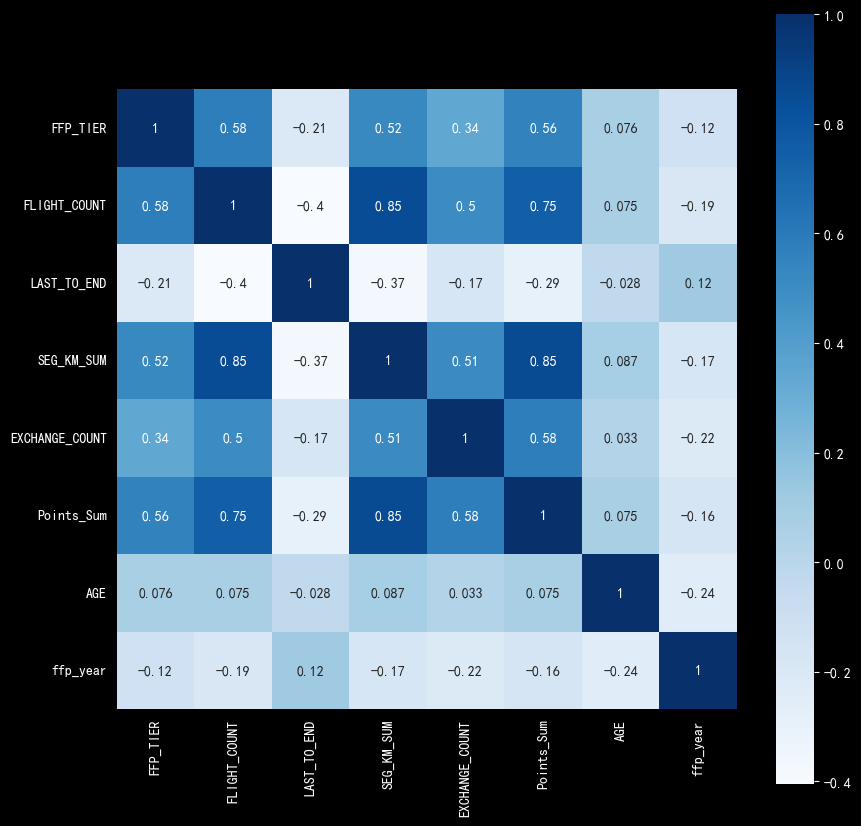

In [54]:
#相关性分析
data_corr = air_data[['FFP_TIER','FLIGHT_COUNT','LAST_TO_END','SEG_KM_SUM','EXCHANGE_COUNT','Points_Sum']].copy()
age1 = air_data['AGE'].fillna(0)
data_corr.loc[:,'AGE'] = age1.astype('int64')
data_corr.loc[:,'ffp_year'] = ffp_year
dt_corr = data_corr.corr(method = 'pearson')
print('相关性矩阵为：\n',dt_corr)
plt.subplots(figsize=(10,10))
sns.heatmap(dt_corr,annot=True,vmax=1,square=True,cmap='Blues')

In [71]:
#数据预处理
cleanedfile = './data_cleaned.csv'
airline_data = pd.read_csv(air_data_path,encoding='utf-8')
print('原始数据形状为：',airline_data.shape)
airline_notnull = airline_data.loc[
    airline_data['SUM_YR_1'].notnull() & airline_data['SUM_YR_2'].notnull(),:
]
print('删除缺失记录后数据的形状为：',airline_notnull.shape)
# 只保留票价非零的，或者平均折扣率不为0且总飞行公里数大于0的记录。
index1 = airline_notnull['SUM_YR_1'] != 0
index2 = airline_notnull['SUM_YR_2'] != 0
index3 = (airline_notnull['SEG_KM_SUM']>0) & (airline_notnull['avg_discount']!=0)
index4 = airline_notnull['AGE']<100
airline = airline_notnull[(index1 | index2) & index3 & index4]
#print(airline_notnull.columns.tolist())
print('清洗后的数据形状为：',airline.shape)
airline.to_csv(cleanedfile)
print('导出成功！')

原始数据形状为： (62988, 44)
删除缺失记录后数据的形状为： (62299, 44)
清洗后的数据形状为： (61631, 44)
导出成功！


In [73]:
cleanedfile = './data_cleaned.csv'
airline = pd.read_csv(cleanedfile,encoding='utf-8')
airline_selection = airline[['FFP_DATE','LOAD_TIME','LAST_TO_END','FLIGHT_COUNT','SEG_KM_SUM','avg_discount']]
print('筛选的属性前5行为：\n',airline_selection.head())


筛选的属性前5行为：
     FFP_DATE  LOAD_TIME  LAST_TO_END  FLIGHT_COUNT  SEG_KM_SUM  avg_discount
0  2006/11/2  2014/3/31            1           210      580717      0.961639
1  2007/2/19  2014/3/31            7           140      293678      1.252314
2   2007/2/1  2014/3/31           11           135      283712      1.254676
3  2008/8/22  2014/3/31           97            23      281336      1.090870
4  2009/4/10  2014/3/31            5           152      309928      0.970658


In [88]:
#3. 数据转换
#构造属性L(以月为单位)
L = pd.to_datetime(airline_selection['LOAD_TIME']) - pd.to_datetime(airline_selection['FFP_DATE'])
L = L.astype('str').str.split().str[0]
L = L.astype('int64') / 30
#合并属性
airline_features = pd.concat([L,airline_selection.iloc[:,2:]],axis = 1)
airline_features.columns = ['L','R','F','M','C']
print('构建的LRMFMC属性前5行为：\n',airline_features.head())

#数据标准化
from sklearn.preprocessing import StandardScaler
data = StandardScaler().fit_transform(airline_features)
np.savez('./airline_scale.npz',data)
print('标准化后的LRFMC五个属性为：\n',data[:5,:])

构建的LRMFMC属性前5行为：
            L   R    F       M         C
0  90.200000   1  210  580717  0.961639
1  86.566667   7  140  293678  1.252314
2  87.166667  11  135  283712  1.254676
3  68.233333  97   23  281336  1.090870
4  60.533333   5  152  309928  0.970658
标准化后的LRFMC五个属性为：
 [[ 1.44089948 -0.94422735 14.01002301 26.73934818  1.2977838 ]
 [ 1.31225859 -0.91116707  9.05714489 13.11551306  2.87197541]
 [ 1.33350204 -0.88912688  8.70336789 12.64249322  2.88476213]
 [ 0.6631532  -0.41526281  0.7787629  12.52972028  1.99764903]
 [ 0.39052893 -0.92218716  9.90620971 13.88679264  1.3466266 ]]


In [11]:
#K-Means聚类算法
from sklearn.cluster import KMeans
#读取标准化之后的数据
airline_scale = np.load('./airline_scale.npz')['arr_0']
#确定聚类中心的数量（簇数）
k = 5
#实例化模型（这一行代码执行完，你只是在内存里产生了一个“聪明但脑子空空”的机器人（kmeans_model）。你告诉了它规则（分 5 类、重复 4 次），但此时它还没见过你的航空公司数据。它现在只是一个准备就绪的工具。）
kmeans_model = KMeans(n_clusters=k,n_init=4,random_state=123)
#训练模型
fit_kmeans = kmeans_model.fit(airline_scale)
#这一步 得到了“描述数据的模型”。你可以利用这个模型，去产生分类标签和中心点坐标。
# 查看聚类结果
kmeans_cc = kmeans_model.cluster_centers_#查看聚类中心
print('各类聚类中心为：\n',kmeans_cc)
kmeans_labels = kmeans_model.labels_#查看样本的类别标签
print('个样本的类别标签为：\n',kmeans_labels)
r1 = pd.Series(kmeans_model.labels_).value_counts() # 统计每一类各有多少人
print('每一类所含人数：\n',r1)
#输出聚类分群的结果（因为kmeans_cc是numpy数组 但是需要给它一个列名 把它转成表格 这里的Z是指Z-Score标准化之后的数据）
cluster_center = pd.DataFrame(
    kmeans_cc,columns=['ZL','ZR','ZF','ZM','ZC']
)
#将样本类别作为数据框索引(把整个数据表去重，留下0-4 五个数字，并取出这一列作为index，太麻烦)
cluster_center.index = pd.DataFrame(kmeans_labels).drop_duplicates().iloc[:,0]
#更简洁的方法：cluster_center.index = range(len(cluster_center))
print('cluster_center为：\n',cluster_center)

各类聚类中心为：
 [[-6.98638291e-01 -4.19827448e-01 -1.55981149e-01 -1.52697132e-01
  -3.03292948e-01]
 [ 4.87548978e-01 -7.99408236e-01  2.48037514e+00  2.42070345e+00
   3.24591343e-01]
 [ 1.17511603e+00 -3.79547090e-01 -8.12388626e-02 -8.82335866e-02
  -1.63740615e-01]
 [-3.09139900e-01  1.70094131e+00 -5.75376463e-01 -5.36417262e-01
  -2.03942047e-01]
 [-7.24518457e-02  1.51307897e-03 -2.70455915e-01 -2.90757295e-01
   1.88733475e+00]]
个样本的类别标签为：
 [1 1 1 ... 0 3 3]
每一类所含人数：
 0    23741
2    15333
3    11776
4     5458
1     5323
Name: count, dtype: int64
cluster_center为：
          ZL        ZR        ZF        ZM        ZC
0                                                  
1 -0.698638 -0.419827 -0.155981 -0.152697 -0.303293
4  0.487549 -0.799408  2.480375  2.420703  0.324591
2  1.175116 -0.379547 -0.081239 -0.088234 -0.163741
0 -0.309140  1.700941 -0.575376 -0.536417 -0.203942
3 -0.072452  0.001513 -0.270456 -0.290757  1.887335


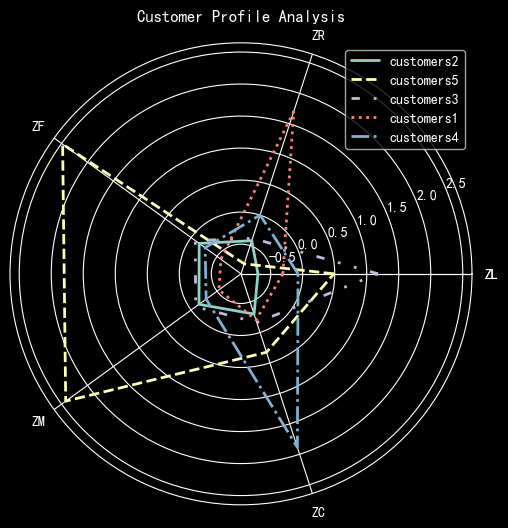

In [16]:
#绘制雷达图
labels = ['ZL','ZR','ZF','ZM','ZC']
legen = ['customers'+ str(i+1) for i in cluster_center.index]#客户群命名
lstype = ['-','--',(0,(3,5,1,5,1,5)),':','-.']#定义不同的线性
kinds = list(cluster_center.iloc[:,0])
# 由于雷达图要保证数据闭合，因此再添加L列，并转换为 np.ndarray
plot_data = cluster_center
plot_data = pd.concat([cluster_center, cluster_center[['ZL']]], axis= 1)
centers = np.array(plot_data)
#分割圆周长并闭合
n = len(labels)
angle = np.linspace(0,2*np.pi,n,endpoint=False)
angle = np.concatenate((angle,[angle[0]]))
plot_labels = labels + [labels[0]]
#绘图
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111,polar=True)
for i in range(len(kinds)):
    ax.plot(angle,centers[i],linestyle=lstype[i],linewidth=2, label=kinds[i])
# 属性标签
ax.set_thetagrids(angle * 180 / np.pi, plot_labels)
plt.title('Customer Profile Analysis')
plt.legend(legen)
